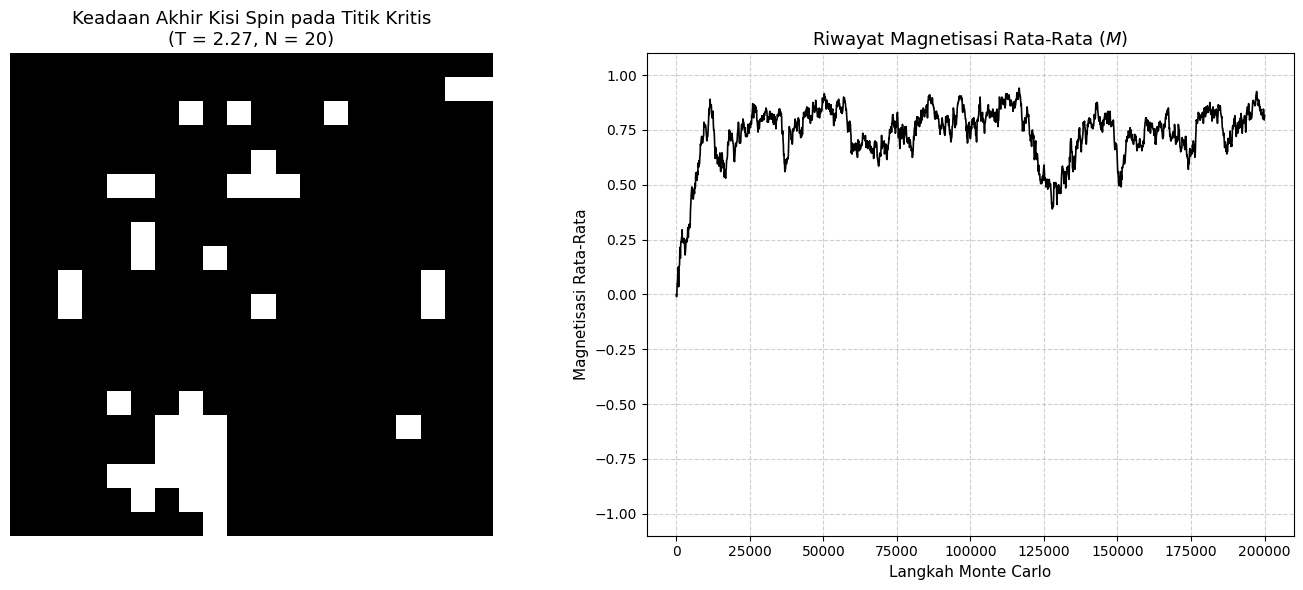

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameter Simulasi
# ==========================================
N = 20                 # Ukuran kisi N x N
T = 2.27               # Suhu Kritis Teoritis (T ≈ Tc)
MC_STEPS = 200000      # Total langkah Monte Carlo
RECORD_INTERVAL = 100  # Interval pengambilan sampel makrostate

# ==========================================
# Inisialisasi Sistem
# ==========================================
# Hot Start: Konfigurasi acak untuk merepresentasikan entropi maksimum
grid = np.random.choice([-1, 1], size=(N, N))

# Array penampung data makrostate
magnetization_history = []
time_steps = []

def calculate_magnetization(config):
    """Menghitung nilai rata-rata magnetisasi kisi"""
    return np.sum(config) / (N * N)

# Catat kondisi awal sebelum loop
magnetization_history.append(calculate_magnetization(grid))
time_steps.append(0)

# Pra-kalkulasi faktor Boltzmann untuk menghemat komputasi di dalam loop
exp_dE = {dE: np.exp(-dE / T) for dE in [-8, -4, 0, 4, 8]}

# ==========================================
# Loop Algoritma Metropolis-Hastings
# ==========================================
for step in range(1, MC_STEPS + 1):
    # 1. Pilih spin secara acak di dalam kisi
    i, j = np.random.randint(0, N, size=2)

    # 2. Ambil nilai spin saat ini dan tetangga terdekat dengan Syarat Batas Periodik (PBC)
    spin = grid[i, j]
    neighbors = (grid[(i + 1) % N, j] +
                 grid[(i - 1) % N, j] +
                 grid[i, (j + 1) % N] +
                 grid[i, (j - 1) % N])

    # 3. Hitung perubahan energi potensial (dE) jika spin dibalik
    dE = 2 * spin * neighbors

    # 4. Evaluasi Probabilitas Metropolis
    if dE <= 0 or np.random.rand() < exp_dE[dE]:
        grid[i, j] *= -1  # Terima pembalikan spin

    # 5. Pencatatan Berkala Makrostate
    if step % RECORD_INTERVAL == 0:
        magnetization_history.append(calculate_magnetization(grid))
        time_steps.append(step)

# ==========================================
# Visualisasi Hasil Simulasi
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 左: Konfigurasi Akhir Kisi Spin (Peta Warna Biner)
im = axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f'Keadaan Akhir Kisi Spin pada Titik Kritis\n(T = {T}, N = {N})', fontsize=13)
axes[0].axis('off')

# Plot 右: Kurva Riwayat Magnetisasi Sepanjang Waktu Simulasi
axes[1].plot(time_steps, magnetization_history, color='black', linewidth=1.2)
axes[1].set_title('Riwayat Magnetisasi Rata-Rata ($M$)', fontsize=13)
axes[1].set_xlabel('Langkah Monte Carlo', fontsize=11)
axes[1].set_ylabel('Magnetisasi Rata-Rata', fontsize=11)
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()